In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
os.chdir(project_root)  # 👈 this changes the working directory
sys.path.append(project_root)

print("New working directory:", os.getcwd())

New working directory: C:\Users\Atharva Kulkarni\Desktop\Programming\ML PROJECTS\SIEM\SIEM project\AI-driven-SIEM-System\model


In [3]:
# Configure plotting
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load your parsed log dataset
df = pd.read_csv("data/logs/processed/Linux.log_structured.csv")   # Replace with your file path

# Basic structure
print(df.shape)
print(df.dtypes)
print(df.head())

(25456, 10)
LineId             int64
Month             object
Date               int64
Time              object
Level             object
Component         object
PID              float64
Content           object
EventId           object
EventTemplate     object
dtype: object
   LineId Month  Date      Time  Level      Component  PID  \
0       1   Jun     9  06:06:20  combo  syslogd 1.4.1  NaN   
1       2   Jun     9  06:06:20  combo         syslog  NaN   
2       3   Jun     9  06:06:20  combo         syslog  NaN   
3       4   Jun     9  06:06:20  combo         kernel  NaN   
4       5   Jun     9  06:06:20  combo         kernel  NaN   

                                             Content EventId  \
0                                           restart.      E0   
1                          syslogd startup succeeded     E10   
2                            klogd startup succeeded     E12   
3      klogd 1.4.1, log source = /proc/kmsg started.    E114   
4  Linux version 2.6.5-1.358 (b

In [4]:
# Convert Time to datetime for temporal analysis
df['Datetime'] = pd.to_datetime(df['Month'] + ' ' + df['Date'].astype(str) + ' ' + df['Time'],
                                format='%b %d %H:%M:%S', errors='coerce')

# Handle missing values
print(df.isna().sum())
df.fillna({'PID': 0}, inplace=True)

# Normalize Level & Component
df['Level'] = df['Level'].str.lower().str.strip()
df['Component'] = df['Component'].str.replace(r'[\(\)]', '', regex=True).str.strip()

# Derived columns
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['Day'] = df['Datetime'].dt.day


LineId               0
Month                0
Date                 0
Time                 0
Level                0
Component            0
PID              14414
Content              0
EventId              0
EventTemplate        0
Datetime             0
dtype: int64


In [5]:
print("Unique components:", df['Component'].nunique())
print("Unique event templates:", df['EventTemplate'].nunique())

# Frequency counts
print(df['Level'].value_counts())
print(df['Component'].value_counts().head(10))


Unique components: 72
Unique event templates: 519
Level
combo    25456
Name: count, dtype: int64
Component
kernel          13581
sshdpam_unix     4996
ftpd             3453
supam_unix        944
udev              484
named             320
logrotate         231
telnetd           179
unix_chkpwd       153
smartd             92
Name: count, dtype: int64


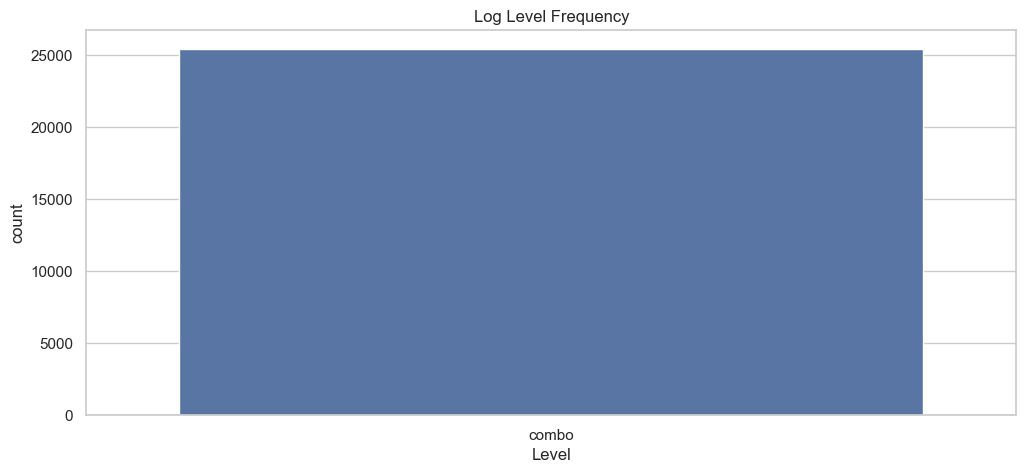

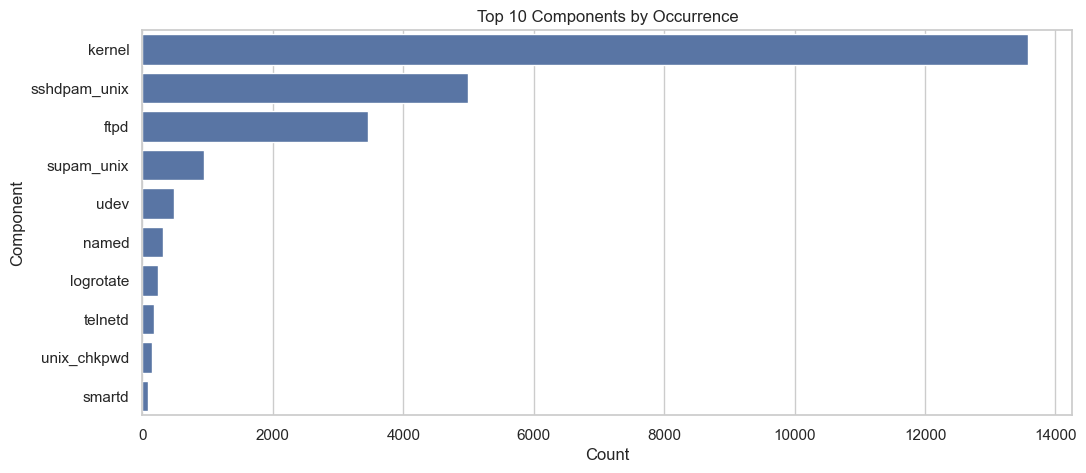

In [6]:
# Log level distribution
sns.countplot(x='Level', data=df, order=df['Level'].value_counts().index)
plt.title('Log Level Frequency')
plt.show()

# Top 10 Components
top_components = df['Component'].value_counts().nlargest(10)
sns.barplot(x=top_components.values, y=top_components.index)
plt.title('Top 10 Components by Occurrence')
plt.xlabel('Count')
plt.ylabel('Component')
plt.show()


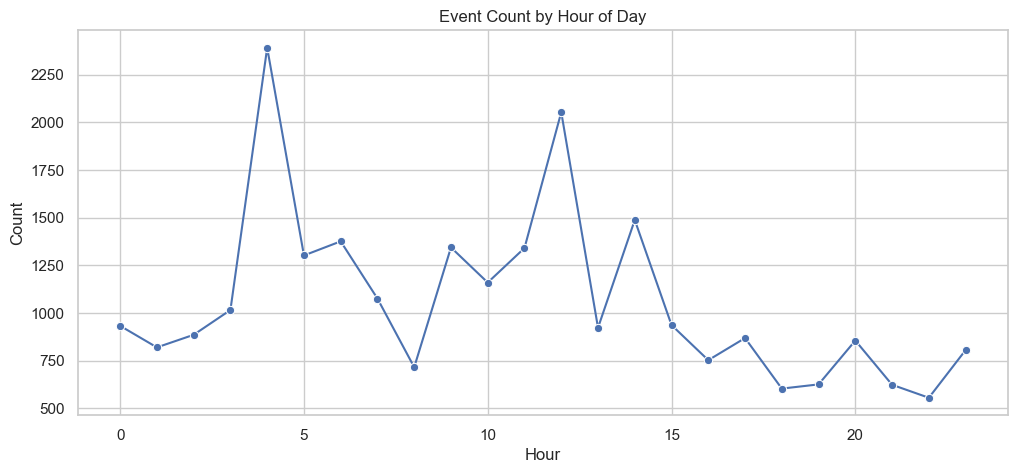

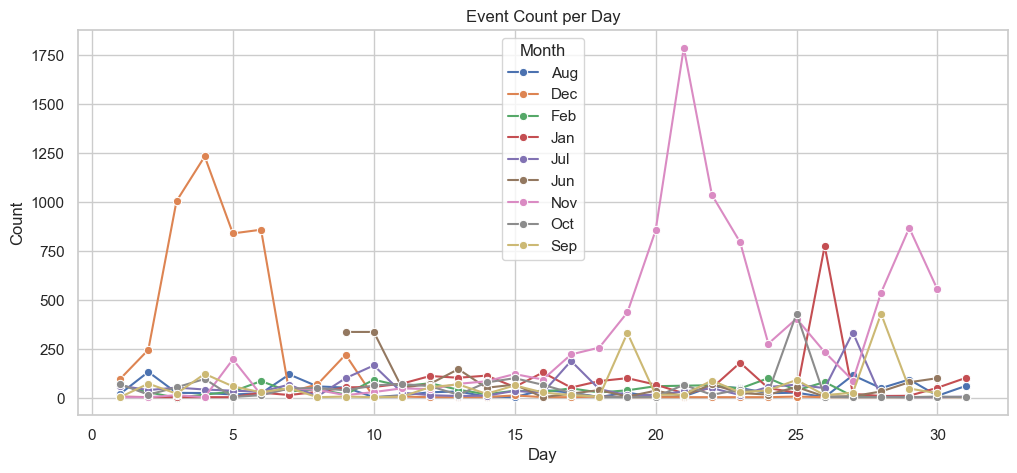

In [7]:
# Events over time (by hour)
hourly = df.groupby('Hour').size().reset_index(name='Count')
sns.lineplot(x='Hour', y='Count', data=hourly, marker='o')
plt.title('Event Count by Hour of Day')
plt.show()

# If dataset covers multiple days or months:
daily = df.groupby(['Month', 'Day']).size().reset_index(name='Count')
sns.lineplot(x='Day', y='Count', hue='Month', data=daily, marker='o')
plt.title('Event Count per Day')
plt.show()


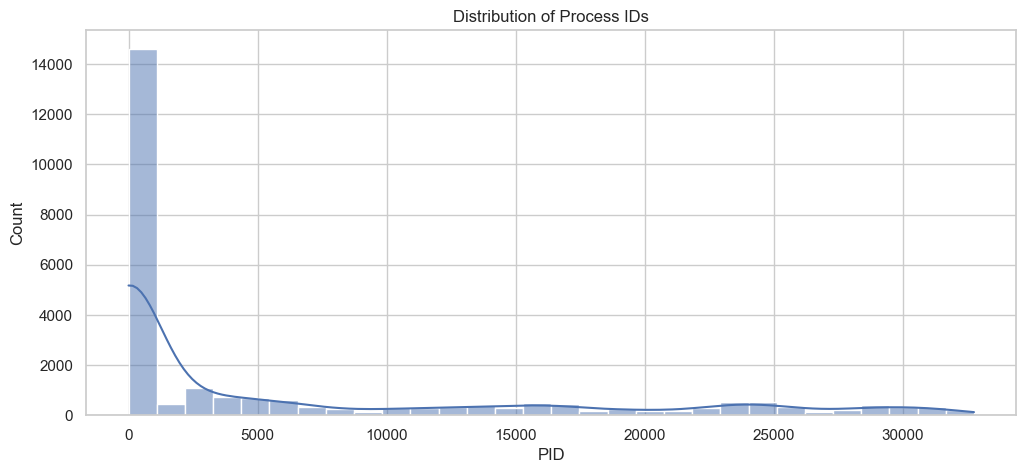

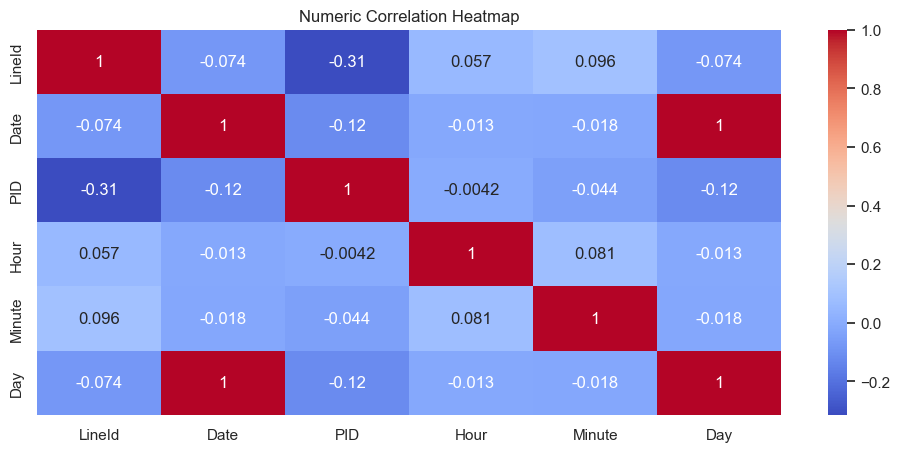

In [8]:
# PID distribution
sns.histplot(df['PID'], bins=30, kde=True)
plt.title('Distribution of Process IDs')
plt.show()

# Correlation (if numeric columns exist)
numeric_cols = df.select_dtypes(include=[np.number])
if not numeric_cols.empty:
    sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
    plt.title('Numeric Correlation Heatmap')
    plt.show()


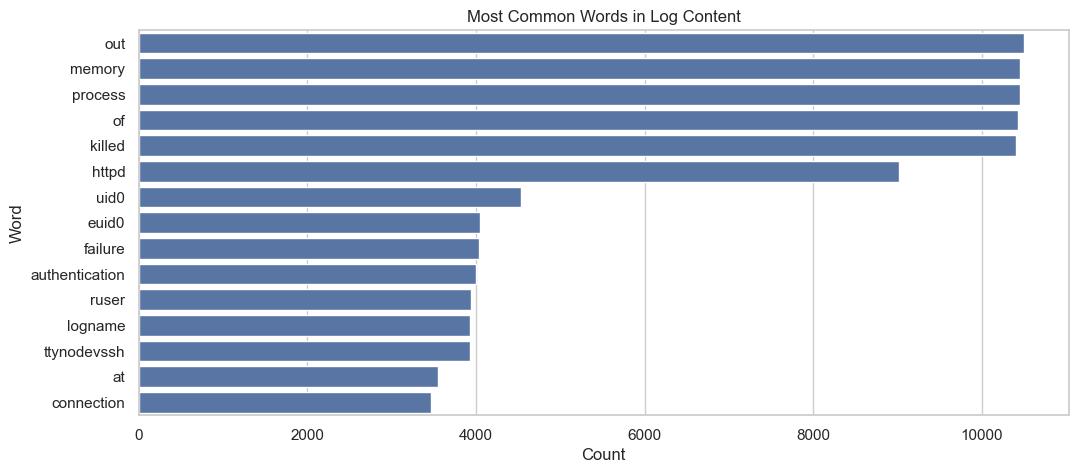

In [10]:
# Most frequent words in Content
from collections import Counter
import re

words = df['Content'].str.lower().str.replace(r'[^a-z0-9 ]', '', regex=True).str.split()
all_words = [w for sublist in words.dropna() for w in sublist]
common_words = Counter(all_words).most_common(15)

cw_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=cw_df)
plt.title('Most Common Words in Log Content')
plt.show()


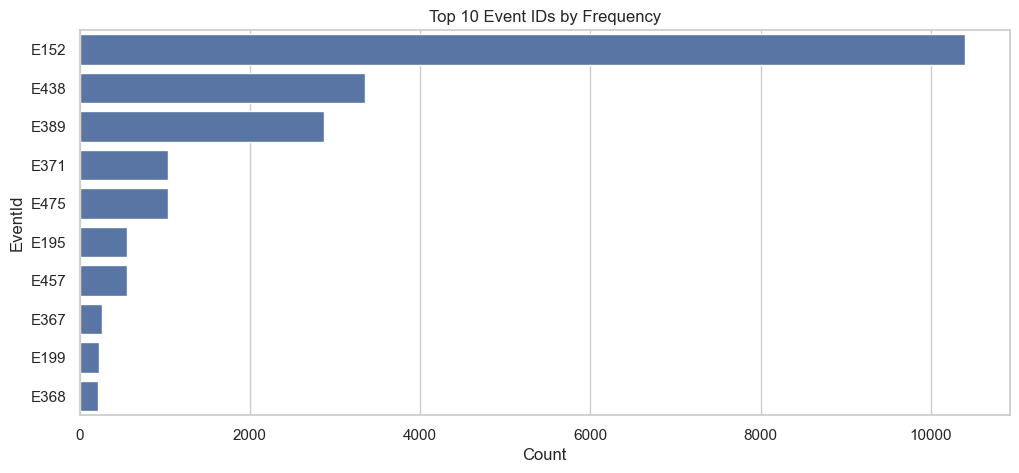

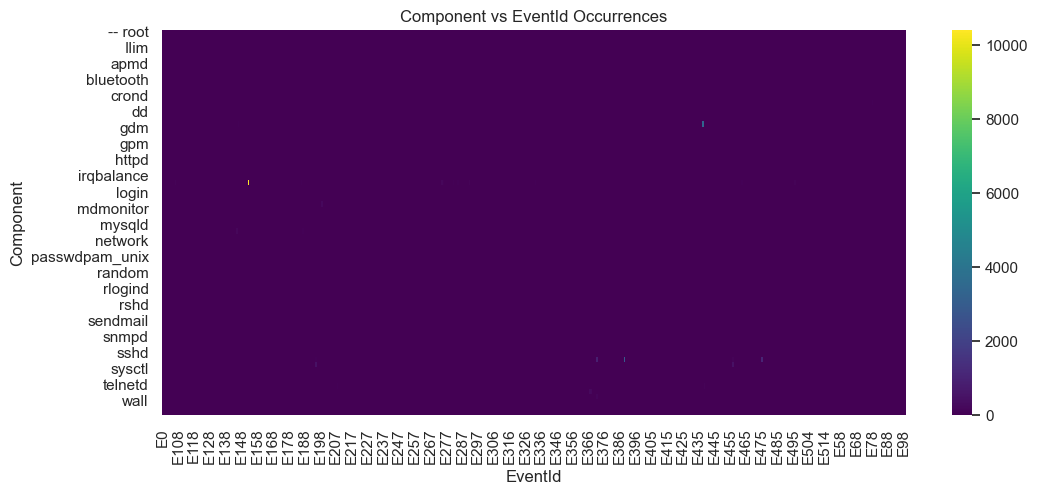

In [11]:
# Event frequency
event_counts = df['EventId'].value_counts().head(10)
sns.barplot(x=event_counts.values, y=event_counts.index)
plt.title('Top 10 Event IDs by Frequency')
plt.xlabel('Count')
plt.ylabel('EventId')
plt.show()

# Component vs EventId cross-tab
ct = pd.crosstab(df['Component'], df['EventId'])
sns.heatmap(ct, cmap='viridis', cbar=True)
plt.title('Component vs EventId Occurrences')
plt.show()


In [12]:
# Identify components generating rare event IDs
event_freq = df['EventId'].value_counts()
rare_events = event_freq[event_freq < 5].index
rare_logs = df[df['EventId'].isin(rare_events)]
print("Rare event count:", len(rare_logs))
print(rare_logs[['Datetime', 'Component', 'EventId', 'Content']].head())


Rare event count: 353
               Datetime Component EventId  \
157 1900-06-09 06:06:26    kernel    E138   
158 1900-06-09 06:06:26    kernel    E455   
160 1900-06-09 06:06:26    kernel    E139   
161 1900-06-09 06:06:27    kernel    E408   
162 1900-06-09 06:06:27    kernel     E77   

                                               Content  
157  EXT3-fs: INFO: recovery required on readonly f...  
158  EXT3-fs: write access will be enabled during r...  
160       EXT3-fs: hda2: orphan cleanup on readonly fs  
161             EXT3-fs: hda2: 4 orphan inodes deleted  
162                        EXT3-fs: recovery complete.  


In [13]:
from scipy.stats import zscore

# Event frequency
event_counts = df['EventId'].value_counts().reset_index()
event_counts.columns = ['EventId', 'Count']
event_counts['Zscore'] = zscore(event_counts['Count'])

# Define anomaly threshold (|Z| > 2 or 3)
anomalous_events = event_counts[np.abs(event_counts['Zscore']) > 2]
print("Anomalous (rare/frequent) Event IDs:")
print(anomalous_events.sort_values('Zscore'))


Anomalous (rare/frequent) Event IDs:
  EventId  Count     Zscore
2    E389   2876   5.655403
1    E438   3357   6.617658
0    E152  10404  20.715397


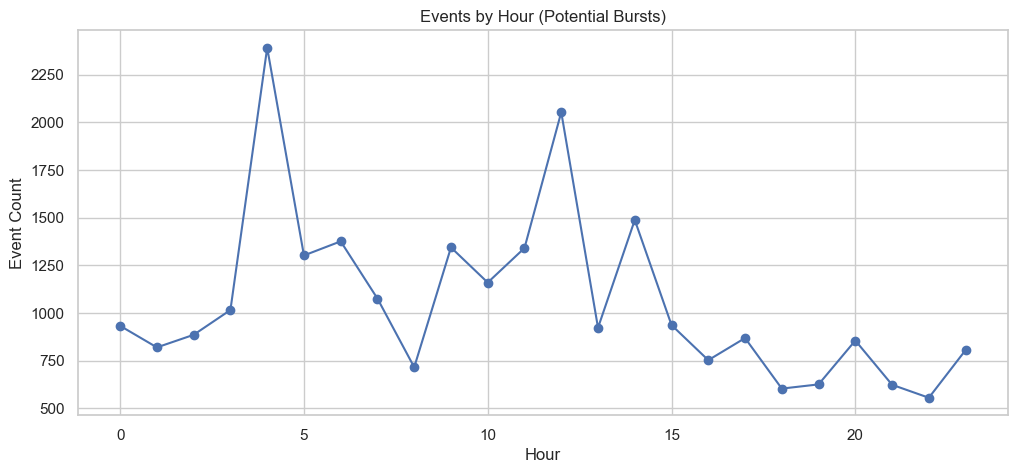

Potential anomaly hours (bursts or quiet periods):
    Hour  Count    Zscore
4      4   2391  3.037205
12    12   2053  2.265537


In [14]:
time_freq = df.groupby('Hour').size().reset_index(name='Count')
time_freq['Zscore'] = zscore(time_freq['Count'])

plt.plot(time_freq['Hour'], time_freq['Count'], marker='o')
plt.title('Events by Hour (Potential Bursts)')
plt.xlabel('Hour')
plt.ylabel('Event Count')
plt.show()

# Highlight anomalies
burst_hours = time_freq[np.abs(time_freq['Zscore']) > 2]
print("Potential anomaly hours (bursts or quiet periods):")
print(burst_hours)


In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# Prepare features
df_model = df.copy()
le_comp = LabelEncoder()
le_event = LabelEncoder()

df_model['Component_enc'] = le_comp.fit_transform(df_model['Component'])
df_model['EventId_enc'] = le_event.fit_transform(df_model['EventId'])
df_model['PID'] = pd.to_numeric(df_model['PID'], errors='coerce').fillna(0)

features = ['PID', 'Hour', 'Component_enc', 'EventId_enc']
X = df_model[features]

# Train Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
df_model['anomaly_score'] = iso.fit_predict(X)

# Label anomalies (-1 = anomaly)
anomalies = df_model[df_model['anomaly_score'] == -1]

print("Detected anomalies:", len(anomalies))
print(anomalies[['Datetime', 'Component', 'EventId', 'PID', 'Content']].head())


Detected anomalies: 510
               Datetime      Component EventId     PID  \
0   1900-06-09 06:06:20  syslogd 1.4.1      E0     0.0   
92  1900-06-09 06:06:22      bluetooth     E73     0.0   
215 1900-06-09 06:06:37           cups     E78     0.0   
217 1900-06-09 06:06:38         xinetd     E80     0.0   
218 1900-06-09 06:06:40         xinetd    E143  2003.0   

                                               Content  
0                                             restart.  
92                              sdpd startup succeeded  
215                            cupsd startup succeeded  
217                           xinetd startup succeeded  
218  No such internal service: services/stream - DI...  


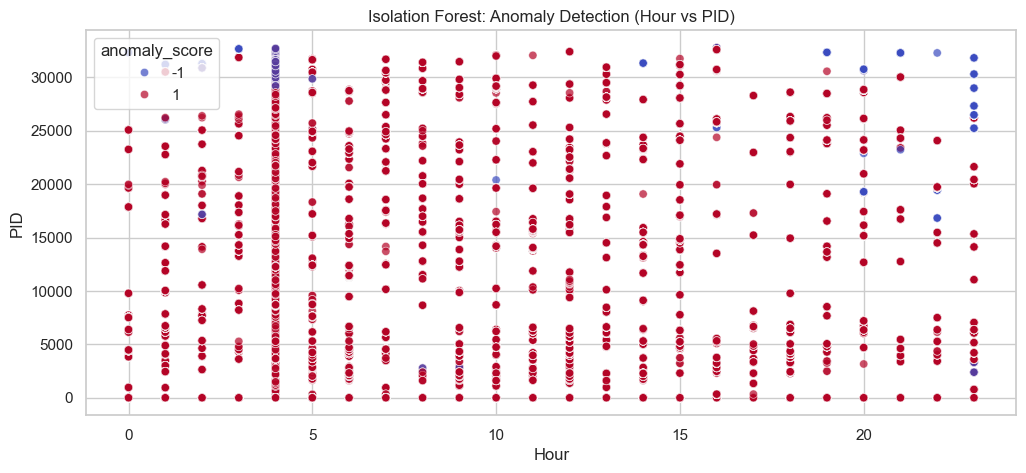

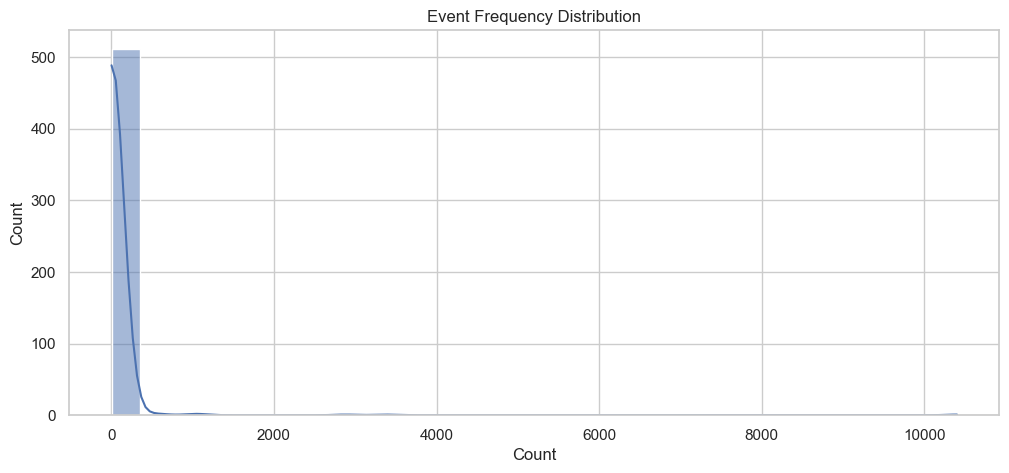

In [16]:
sns.scatterplot(data=df_model, x='Hour', y='PID', hue='anomaly_score', palette='coolwarm', alpha=0.7)
plt.title('Isolation Forest: Anomaly Detection (Hour vs PID)')
plt.show()

# Optionally, plot event frequency with anomalies highlighted
event_freq = df_model.groupby('EventId_enc').size().reset_index(name='Count')
sns.histplot(event_freq['Count'], bins=30, kde=True)
plt.title('Event Frequency Distribution')
plt.show()
